In [2]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [3]:
# ============================================================
# SHAP EXPLAINABILITY + UNSEEN VALIDATION
# STEP 1: PROJECT SETUP
# ============================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Project root exists:", PROJECT_ROOT.exists())

Project root: c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x
Project root exists: True


In [4]:
# ============================================================
# STEP 2: IMPORTS AND DATASET
# ============================================================

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from src.preprocessing.preprocessing import (
    FINAL_FEATURES,
    prepare_features
)

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "phishguard_features.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Number of final features:", len(FINAL_FEATURES))
print("Missing values:", df[FINAL_FEATURES].isna().sum().sum())

Dataset shape: (10000, 18)
Number of final features: 15
Missing values: 0


In [5]:
# ============================================================
# STEP 3: PREPARE FINAL FEATURE MATRIX
# ============================================================

X = prepare_features(df)
y = df["Label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFinal features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

X shape: (10000, 15)
y shape: (10000,)

Final features:
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Web_Forwards']

Target distribution:
Label
0    5000
1    5000
Name: count, dtype: int64


In [6]:
# ============================================================
# STEP 4: CREATE UNSEEN VALIDATION DATA PATH
# ============================================================

VALIDATION_DIR = PROJECT_ROOT / "data" / "validation"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_PATH = VALIDATION_DIR / "unseen_validation.csv"

print("Validation directory:", VALIDATION_DIR)
print("Validation directory exists:", VALIDATION_DIR.exists())
print("Validation file:", VALIDATION_PATH)

Validation directory: c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\validation
Validation directory exists: True
Validation file: c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\validation\unseen_validation.csv


In [7]:
# ============================================================
# STEP 7A: GET NEW LEGITIMATE DOMAINS FROM TRANCO
# ============================================================

import pandas as pd

TRANCO_PATH = PROJECT_ROOT / "data" / "raw" / "tranco_GQJ9K.csv"

tranco = pd.read_csv(
    TRANCO_PATH,
    header=None,
    names=["rank", "domain"]
)

# Original dataset ke domains
original_domains = set(
    df["Domain"]
    .dropna()
    .astype(str)
    .str.lower()
    .str.strip()
)

# Tranco se original domains remove
unseen_legit = tranco[
    ~tranco["domain"].astype(str).str.lower().str.strip().isin(original_domains)
].copy()

print("Tranco shape:", tranco.shape)
print("Original unique domains:", len(original_domains))
print("Unseen legitimate domains:", unseen_legit.shape)

print("\nFirst 20 unseen domains:")
print(unseen_legit.head(20))

Tranco shape: (4384729, 2)
Original unique domains: 3444
Unseen legitimate domains: (4384398, 2)

First 20 unseen domains:
    rank                domain
1      2        cloudflare.com
2      3          facebook.com
3      4           gstatic.com
4      5        googleapis.com
5      6         microsoft.com
6      7         amazonaws.com
7      8            akamai.net
8      9           youtube.com
9     10             apple.com
11    12               mail.ru
12    13            ezviz7.com
13    14             fbcdn.net
15    16               dzen.ru
16    17          linkedin.com
17    18     domaincontrol.com
18    19       googlevideo.com
19    20        hicloudcam.com
20    21            office.com
21    22  googletagmanager.com
22    23              live.com


In [8]:
# ============================================================
# STEP 7B: CREATE UNSEEN LEGITIMATE VALIDATION URLs
# ============================================================

# Take 100 domains from the unseen Tranco list
unseen_legit_sample = unseen_legit.head(100).copy()

# Convert domains into URLs
unseen_legit_sample["URL"] = (
    "https://" + unseen_legit_sample["domain"].astype(str)
)

print("Validation sample shape:", unseen_legit_sample.shape)

print("\nFirst 20 validation URLs:")
print(unseen_legit_sample["URL"].head(20).to_string(index=False))

Validation sample shape: (100, 3)

First 20 validation URLs:
      https://cloudflare.com
        https://facebook.com
         https://gstatic.com
      https://googleapis.com
       https://microsoft.com
       https://amazonaws.com
          https://akamai.net
         https://youtube.com
           https://apple.com
             https://mail.ru
          https://ezviz7.com
           https://fbcdn.net
             https://dzen.ru
        https://linkedin.com
   https://domaincontrol.com
     https://googlevideo.com
      https://hicloudcam.com
          https://office.com
https://googletagmanager.com
            https://live.com


In [9]:
# ============================================================
# STEP 8: RECREATE TUNED XGBOOST MODEL
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier

# Domain-aware split — same settings used earlier
groups = df["Domain"].astype(str)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train_domain = X.iloc[train_idx].copy()
X_test_domain = X.iloc[test_idx].copy()

y_train_domain = y.iloc[train_idx].copy()
y_test_domain = y.iloc[test_idx].copy()

print("X_train:", X_train_domain.shape)
print("X_test:", X_test_domain.shape)

# Best parameters obtained from domain-aware GridSearchCV
tuned_xgb_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

tuned_xgb_model.fit(
    X_train_domain,
    y_train_domain
)

print("\nTuned XGBoost trained successfully.")

X_train: (8538, 15)
X_test: (1462, 15)

Tuned XGBoost trained successfully.


In [10]:
# ============================================================
# STEP 10: CHECK EXISTING LEGITIMATE AUGMENTATION DATA
# ============================================================

import pandas as pd

files_to_check = [
    "improved_legitimate_raw.csv",
    "augmented_legitimate_features.csv"
]

for filename in files_to_check:

    path = PROJECT_ROOT / "data" / "processed" / filename

    print("\n" + "=" * 60)
    print("FILE:", filename)
    print("=" * 60)

    if path.exists():

        temp = pd.read_csv(path)

        print("Shape:", temp.shape)
        print("Columns:", temp.columns.tolist())
        print("\nFirst 5 rows:")
        print(temp.head())

    else:
        print("File not found.")


FILE: improved_legitimate_raw.csv
Shape: (5000, 2)
Columns: ['URL', 'Domain']

First 5 rows:
                                                 URL     Domain
0  http://1337x.to/torrent/1154311/Battle-For-Sky...   1337x.to
1  http://189.cn/dqmh/userCenter/myOrderInfoList....     189.cn
2  http://2gis.ru/moscow/search/%D0%93%D0%BE%D1%8...    2gis.ru
3  https://500px.com/photo/13311139/rojo-pasi%C3%...  500px.com
4  http://9gag.tv/p/a9arrN/watching-these-guys-tr...    9gag.tv

FILE: augmented_legitimate_features.csv
Shape: (5000, 18)
Columns: ['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

First 5 rows:
             Domain  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  \
0        tobogo.net        0        0           1          2            0   
1  graphicriver.net        0        0        

In [11]:
# ============================================================
# STEP 10A: PREPARE 500 NEW LEGITIMATE TRAINING URLS
# ============================================================

# First 100 domains are reserved for external validation.
# Start from the 101st unseen domain.

augmentation_legit = unseen_legit.iloc[100:600].copy()

# Create homepage URLs
augmentation_legit["URL"] = (
    "https://" + augmentation_legit["domain"].astype(str)
)

# Safety check: no overlap with external validation
validation_domains = set(
    unseen_legit_sample["domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

augmentation_domains = set(
    augmentation_legit["domain"]
    .astype(str)
    .str.lower()
    .str.strip()
)

overlap = validation_domains.intersection(augmentation_domains)

print("Augmentation samples:", len(augmentation_legit))
print("Validation overlap:", len(overlap))

print("\nFirst 20 augmentation URLs:")
print(
    augmentation_legit["URL"]
    .head(20)
    .to_string(index=False)
)

Augmentation samples: 500
Validation overlap: 0

First 20 augmentation URLs:
                 https://b-cdn.net
                    https://nic.ru
                   https://aws.dev
             https://office365.com
                  https://yccdn.ru
      https://google-analytics.com
               https://outlook.com
                  https://okcdn.ru
              https://afternic.com
     https://registrar-servers.com
                 https://github.io
           https://amazonvideo.com
https://app-analytics-services.com
       https://app-measurement.com
                https://criteo.com
                 https://cdn77.org
                https://apache.org
               https://unity3d.com
       https://amazon-adsystem.com
              https://snapchat.com


In [22]:
import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

from src.features import url_features as uf


# ============================================================
# PATHS
# ============================================================

OUTPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "augmented_legitimate_features.csv"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_FILE = (
    CHECKPOINT_DIR
    / "augmentation_checkpoint.csv"
)


# ============================================================
# AUGMENTATION URLS
# ============================================================

urls = augmentation_legit["URL"].tolist()

print(
    "Total augmentation URLs:",
    len(urls)
)


# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_one(url):

    try:

        result = uf.featureExtraction(
            url,
            0
        )

        if (
            result is not None
            and len(result) == len(uf.feature_names)
        ):
            return result

        return None

    except Exception:
        return None


# ============================================================
# PARALLEL EXTRACTION
# ============================================================

all_results = []

start_time = time.time()

BATCH_SIZE = 50
MAX_WORKERS = 5


for batch_start in range(
    0,
    len(urls),
    BATCH_SIZE
):

    batch_urls = urls[
        batch_start:batch_start + BATCH_SIZE
    ]

    batch_results = []

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        futures = [
            executor.submit(
                extract_one,
                url
            )
            for url in batch_urls
        ]

        for future in as_completed(futures):

            result = future.result()

            if result is not None:
                batch_results.append(result)

    all_results.extend(
        batch_results
    )

    completed = min(
        batch_start + BATCH_SIZE,
        len(urls)
    )

    elapsed = time.time() - start_time

    print(
        f"Completed: {completed}/{len(urls)} | "
        f"Successful: {len(all_results)} | "
        f"Failed: {completed - len(all_results)} | "
        f"Time: {elapsed / 60:.2f} min",
        flush=True
    )

    # ========================================================
    # CHECKPOINT
    # ========================================================

    checkpoint_df = pd.DataFrame(
        all_results,
        columns=uf.feature_names
    )

    checkpoint_df.to_csv(
        CHECKPOINT_FILE,
        index=False
    )


# ============================================================
# FINAL DATAFRAME
# ============================================================

augmented_legitimate_features = pd.DataFrame(
    all_results,
    columns=uf.feature_names
)


# ============================================================
# FINAL SAVE
# ============================================================

augmented_legitimate_features.to_csv(
    OUTPUT_FILE,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

elapsed = time.time() - start_time

print(
    "\n========== AUGMENTATION EXTRACTION COMPLETE =========="
)

print(
    f"Successful: {len(all_results)}/{len(urls)}"
)

print(
    f"Failed: {len(urls) - len(all_results)}"
)

print(
    f"Time: {elapsed / 60:.2f} min"
)

print(
    f"Shape: {augmented_legitimate_features.shape}"
)

print(
    f"Columns: {len(augmented_legitimate_features.columns)}"
)

print(
    f"Saved: {OUTPUT_FILE}"
)

print(
    f"Checkpoint: {CHECKPOINT_FILE}"
)

Tranco domains loaded: 4384729
Total augmentation URLs: 500


In [12]:
# ============================================================
# STEP 10C: VERIFY AUGMENTATION DATA
# ============================================================

import pandas as pd

OUTPUT_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "augmented_legitimate_features.csv"
)

augmented_legitimate_features = pd.read_csv(
    OUTPUT_FILE
)

print("========== AUGMENTATION DATA VERIFICATION ==========")

print("\nShape:")
print(augmented_legitimate_features.shape)

print("\nColumns:")
print(
    augmented_legitimate_features.columns.tolist()
)

print("\nMissing values:")
print(
    augmented_legitimate_features.isna().sum().sum()
)

print("\nLabel distribution:")
print(
    augmented_legitimate_features["Label"]
    .value_counts()
    .sort_index()
)

print("\nDuplicate rows:")
print(
    augmented_legitimate_features.duplicated().sum()
)

print("\nSaved file:")
print(OUTPUT_FILE)

========== AUGMENTATION DATA VERIFICATION ==========

Shape:
(500, 18)

Columns:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']

Missing values:
0

Label distribution:
Label
0    500
Name: count, dtype: int64

Duplicate rows:
0

Saved file:
c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\validation\augmented_legitimate_features.csv


In [13]:
# ============================================================
# STEP 10D: COMBINE ORIGINAL + AUGMENTATION DATA
# ============================================================

import pandas as pd

ORIGINAL_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features.csv"
)

AUGMENTATION_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "augmented_legitimate_features.csv"
)

COMBINED_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_augmented.csv"
)


# ============================================================
# LOAD DATA
# ============================================================

original_df = pd.read_csv(
    ORIGINAL_FILE
)

augmentation_df = pd.read_csv(
    AUGMENTATION_FILE
)


# ============================================================
# COMBINE
# ============================================================

combined_df = pd.concat(
    [
        original_df,
        augmentation_df
    ],
    ignore_index=True
)


# ============================================================
# SAVE
# ============================================================

combined_df.to_csv(
    COMBINED_FILE,
    index=False
)


# ============================================================
# VERIFICATION
# ============================================================

print("========== COMBINED DATASET ==========")

print("\nOriginal shape:")
print(original_df.shape)

print("\nAugmentation shape:")
print(augmentation_df.shape)

print("\nCombined shape:")
print(combined_df.shape)

print("\nLabel distribution:")
print(
    combined_df["Label"]
    .value_counts()
    .sort_index()
)

print("\nMissing values:")
print(
    combined_df.isna().sum().sum()
)

print("\nDuplicate rows:")
print(
    combined_df.duplicated().sum()
)

print("\nSaved:")
print(COMBINED_FILE)

========== COMBINED DATASET ==========

Original shape:
(10000, 18)

Augmentation shape:
(500, 18)

Combined shape:
(10500, 18)

Label distribution:
Label
0    5500
1    5000
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
6169

Saved:
c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\phishguard_features_augmented.csv


In [14]:
# ============================================================
# STEP 10E: DOMAIN-AWARE TRAIN / TEST SPLIT
# ============================================================

import pandas as pd

from sklearn.model_selection import GroupShuffleSplit

from src.preprocessing.preprocessing import (
    FINAL_FEATURES,
    prepare_features
)


# ============================================================
# LOAD AUGMENTED DATASET
# ============================================================

AUGMENTED_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_augmented.csv"
)

df_aug = pd.read_csv(
    AUGMENTED_FILE
)


# ============================================================
# FEATURES + TARGET
# ============================================================

X_aug = prepare_features(df_aug)

y_aug = df_aug["Label"].copy()

groups_aug = (
    df_aug["Domain"]
    .astype(str)
)


# ============================================================
# DOMAIN-AWARE SPLIT
# ============================================================

gss_aug = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_aug, test_idx_aug = next(
    gss_aug.split(
        X_aug,
        y_aug,
        groups=groups_aug
    )
)


X_train_aug = X_aug.iloc[
    train_idx_aug
].copy()

X_test_aug = X_aug.iloc[
    test_idx_aug
].copy()

y_train_aug = y_aug.iloc[
    train_idx_aug
].copy()

y_test_aug = y_aug.iloc[
    test_idx_aug
].copy()


# ============================================================
# VERIFICATION
# ============================================================

train_domains_aug = set(
    groups_aug.iloc[train_idx_aug]
)

test_domains_aug = set(
    groups_aug.iloc[test_idx_aug]
)

domain_overlap_aug = (
    train_domains_aug
    .intersection(test_domains_aug)
)


print("========== AUGMENTED DOMAIN-AWARE SPLIT ==========")

print("\nFull dataset:")
print(X_aug.shape)

print("\nTraining:")
print(X_train_aug.shape)

print("\nTesting:")
print(X_test_aug.shape)

print("\nTraining labels:")
print(
    y_train_aug.value_counts()
    .sort_index()
)

print("\nTesting labels:")
print(
    y_test_aug.value_counts()
    .sort_index()
)

print("\nTraining domains:")
print(len(train_domains_aug))

print("\nTesting domains:")
print(len(test_domains_aug))

print("\nDomain overlap:")
print(len(domain_overlap_aug))

print(
    "\nSTATUS:",
    "PASS - No domain overlap"
    if len(domain_overlap_aug) == 0
    else "FAIL - Domain overlap detected"
)

========== AUGMENTED DOMAIN-AWARE SPLIT ==========

Full dataset:
(10500, 15)

Training:
(8528, 15)

Testing:
(1972, 15)

Training labels:
Label
0    4332
1    4196
Name: count, dtype: int64

Testing labels:
Label
0    1168
1     804
Name: count, dtype: int64

Training domains:
3154

Testing domains:
789

Domain overlap:
0

STATUS: PASS - No domain overlap


In [15]:
# ============================================================
# STEP 10F: TRAIN AUGMENTED TUNED XGBOOST
# ============================================================

from xgboost import XGBClassifier


# ============================================================
# MODEL
# ============================================================

tuned_xgb_aug = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)


# ============================================================
# TRAIN
# ============================================================

tuned_xgb_aug.fit(
    X_train_aug,
    y_train_aug
)


print("========== AUGMENTED XGBOOST TRAINING ==========")
print("Model trained successfully.")
print("Training samples:", X_train_aug.shape[0])
print("Features:", X_train_aug.shape[1])

========== AUGMENTED XGBOOST TRAINING ==========
Model trained successfully.
Training samples: 8528
Features: 15


In [16]:
# ============================================================
# STEP 10G: EVALUATE AUGMENTED XGBOOST
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# PREDICTIONS
# ============================================================

y_pred_aug = tuned_xgb_aug.predict(
    X_test_aug
)

y_prob_aug = tuned_xgb_aug.predict_proba(
    X_test_aug
)[:, 1]


# ============================================================
# METRICS
# ============================================================

accuracy_aug = accuracy_score(
    y_test_aug,
    y_pred_aug
)

precision_aug = precision_score(
    y_test_aug,
    y_pred_aug,
    zero_division=0
)

recall_aug = recall_score(
    y_test_aug,
    y_pred_aug,
    zero_division=0
)

f1_aug = f1_score(
    y_test_aug,
    y_pred_aug,
    zero_division=0
)

roc_auc_aug = roc_auc_score(
    y_test_aug,
    y_prob_aug
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm_aug = confusion_matrix(
    y_test_aug,
    y_pred_aug
)


# ============================================================
# RESULTS
# ============================================================

print("========== AUGMENTED XGBOOST RESULTS ==========")

print(f"Accuracy : {accuracy_aug:.4f}")
print(f"Precision: {precision_aug:.4f}")
print(f"Recall   : {recall_aug:.4f}")
print(f"F1       : {f1_aug:.4f}")
print(f"ROC-AUC  : {roc_auc_aug:.4f}")

print("\nConfusion Matrix:")
print(cm_aug)


# ============================================================
# COMPARISON WITH PREVIOUS TUNED MODEL
# ============================================================

print("\n========== COMPARISON ==========")

print("Previous Tuned XGBoost:")
print("Accuracy : 0.9207")
print("Precision: 0.9971")
print("Recall   : 0.8557")
print("F1       : 0.9210")
print("ROC-AUC  : 0.9645")

print("\nAugmented Tuned XGBoost:")
print(f"Accuracy : {accuracy_aug:.4f}")
print(f"Precision: {precision_aug:.4f}")
print(f"Recall   : {recall_aug:.4f}")
print(f"F1       : {f1_aug:.4f}")
print(f"ROC-AUC  : {roc_auc_aug:.4f}")

========== AUGMENTED XGBOOST RESULTS ==========
Accuracy : 0.9209
Precision: 0.8923
Recall   : 0.9167
F1       : 0.9043
ROC-AUC  : 0.9523

Confusion Matrix:
[[1079   89]
 [  67  737]]

========== COMPARISON ==========
Previous Tuned XGBoost:
Accuracy : 0.9207
Precision: 0.9971
Recall   : 0.8557
F1       : 0.9210
ROC-AUC  : 0.9645

Augmented Tuned XGBoost:
Accuracy : 0.9209
Precision: 0.8923
Recall   : 0.9167
F1       : 0.9043
ROC-AUC  : 0.9523


In [17]:
# ============================================================
# CHECK ORIGINAL 100 UNSEEN SAMPLE
# ============================================================

print("unseen_legit_sample exists:", "unseen_legit_sample" in globals())

if "unseen_legit_sample" in globals():
    print("Shape:", unseen_legit_sample.shape)
    print("\nFirst 10 domains:")
    print(
        unseen_legit_sample["domain"]
        .head(10)
        .tolist()
    )

unseen_legit_sample exists: True
Shape: (100, 3)

First 10 domains:
['cloudflare.com', 'facebook.com', 'gstatic.com', 'googleapis.com', 'microsoft.com', 'amazonaws.com', 'akamai.net', 'youtube.com', 'apple.com', 'mail.ru']


In [25]:
# ============================================================
# STEP 10H: RECREATE ORIGINAL 100 UNSEEN VALIDATION DATA
# WITH CHECKPOINT
# ============================================================

import pandas as pd
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

from src.features import url_features as uf


# ============================================================
# PATHS
# ============================================================

VALIDATION_DIR = (
    PROJECT_ROOT
    / "data"
    / "validation"
)

VALIDATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR = (
    VALIDATION_DIR
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VALIDATION_FILE = (
    VALIDATION_DIR
    / "unseen_validation.csv"
)

CHECKPOINT_FILE = (
    CHECKPOINT_DIR
    / "unseen_legitimate_checkpoint.csv"
)


# ============================================================
# ORIGINAL 100 UNSEEN URLS
# ============================================================

urls = unseen_legit_sample["URL"].tolist()

print(
    "Total unseen validation URLs:",
    len(urls)
)


# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_one(url):

    try:

        result = uf.featureExtraction(
            url,
            0
        )

        if (
            result is not None
            and len(result) == len(uf.feature_names)
        ):
            return result

        return None

    except Exception:
        return None


# ============================================================
# FRESH EXTRACTION
# ============================================================

all_results = []

start_time = time.time()

BATCH_SIZE = 50
MAX_WORKERS = 5


for batch_start in range(
    0,
    len(urls),
    BATCH_SIZE
):

    batch_urls = urls[
        batch_start:batch_start + BATCH_SIZE
    ]

    batch_results = []

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        futures = [
            executor.submit(
                extract_one,
                url
            )
            for url in batch_urls
        ]

        for future in as_completed(futures):

            result = future.result()

            if result is not None:
                batch_results.append(result)

    all_results.extend(
        batch_results
    )

    completed = min(
        batch_start + BATCH_SIZE,
        len(urls)
    )

    elapsed = time.time() - start_time

    print(
        f"Completed: {completed}/{len(urls)} | "
        f"Successful: {len(all_results)} | "
        f"Failed: {completed - len(all_results)} | "
        f"Time: {elapsed / 60:.2f} min",
        flush=True
    )

    # ========================================================
    # CHECKPOINT
    # ========================================================

    checkpoint_df = pd.DataFrame(
        all_results,
        columns=uf.feature_names
    )

    checkpoint_df.to_csv(
        CHECKPOINT_FILE,
        index=False
    )


# ============================================================
# FINAL DATAFRAME
# ============================================================

validation_df = pd.DataFrame(
    all_results,
    columns=uf.feature_names
)


# ============================================================
# FINAL SAVE
# ============================================================

validation_df.to_csv(
    VALIDATION_FILE,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

elapsed = time.time() - start_time

print(
    "\n========== UNSEEN VALIDATION RECREATED =========="
)

print(
    f"Successful: {len(all_results)}/{len(urls)}"
)

print(
    f"Failed: {len(urls) - len(all_results)}"
)

print(
    f"Time: {elapsed / 60:.2f} min"
)

print(
    f"Shape: {validation_df.shape}"
)

print(
    f"Columns: {len(validation_df.columns)}"
)

print(
    f"Saved: {VALIDATION_FILE}"
)

print(
    f"Checkpoint: {CHECKPOINT_FILE}"
)

Tranco domains loaded: 4384729
Total unseen validation URLs: 100


In [18]:
# ============================================================
# STEP 10I: AUGMENTED MODEL ON UNSEEN LEGITIMATE URLS
# ============================================================

import pandas as pd


# ============================================================
# LOAD VALIDATION DATA
# ============================================================

VALIDATION_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "unseen_validation.csv"
)

validation_df = pd.read_csv(
    VALIDATION_FILE
)


# ============================================================
# FEATURES
# ============================================================

X_unseen_aug = validation_df[
    FINAL_FEATURES
].copy()


# ============================================================
# PREDICTION
# ============================================================

y_unseen_pred_aug = tuned_xgb_aug.predict(
    X_unseen_aug
)

y_unseen_prob_aug = tuned_xgb_aug.predict_proba(
    X_unseen_aug
)[:, 1]


# ============================================================
# SUMMARY
# ============================================================

print(
    "========== AUGMENTED MODEL: UNSEEN TEST =========="
)

print(
    "\nTotal unseen legitimate URLs:",
    len(validation_df)
)

print(
    "\nPredicted class distribution:"
)

print(
    pd.Series(
        y_unseen_pred_aug
    ).value_counts().sort_index()
)

print(
    "\nMean phishing probability:",
    f"{y_unseen_prob_aug.mean():.6f}"
)

print(
    "Minimum phishing probability:",
    f"{y_unseen_prob_aug.min():.6f}"
)

print(
    "Maximum phishing probability:",
    f"{y_unseen_prob_aug.max():.6f}"
)


# ============================================================
# FALSE POSITIVES
# ============================================================

false_positives = (
    y_unseen_pred_aug == 1
).sum()

correct_legitimate = (
    y_unseen_pred_aug == 0
).sum()


print(
    "\nFalse positives:",
    false_positives
)

print(
    "Correctly predicted legitimate:",
    correct_legitimate
)

print(
    "False-positive rate:",
    f"{false_positives / len(validation_df):.2%}"
)

========== AUGMENTED MODEL: UNSEEN TEST ==========

Total unseen legitimate URLs: 100

Predicted class distribution:
0    26
1    74
Name: count, dtype: int64

Mean phishing probability: 0.579656
Minimum phishing probability: 0.443606
Maximum phishing probability: 0.873874

False positives: 74
Correctly predicted legitimate: 26
False-positive rate: 74.00%


========== AUGMENTED MODEL SHAP IMPORTANCE ==========
      Feature  Mean_Abs_SHAP
   URL_Length       0.927131
Prefix/Suffix       0.299412
  Web_Traffic       0.203627
 Web_Forwards       0.145315
   Domain_Age       0.144422
   Domain_End       0.144255
    URL_Depth       0.056270
       iFrame       0.043889
   DNS_Record       0.009720
  Redirection       0.002483
   Mouse_Over       0.002425
      TinyURL       0.000000
 https_Domain       0.000000
      Have_IP       0.000000
      Have_At       0.000000


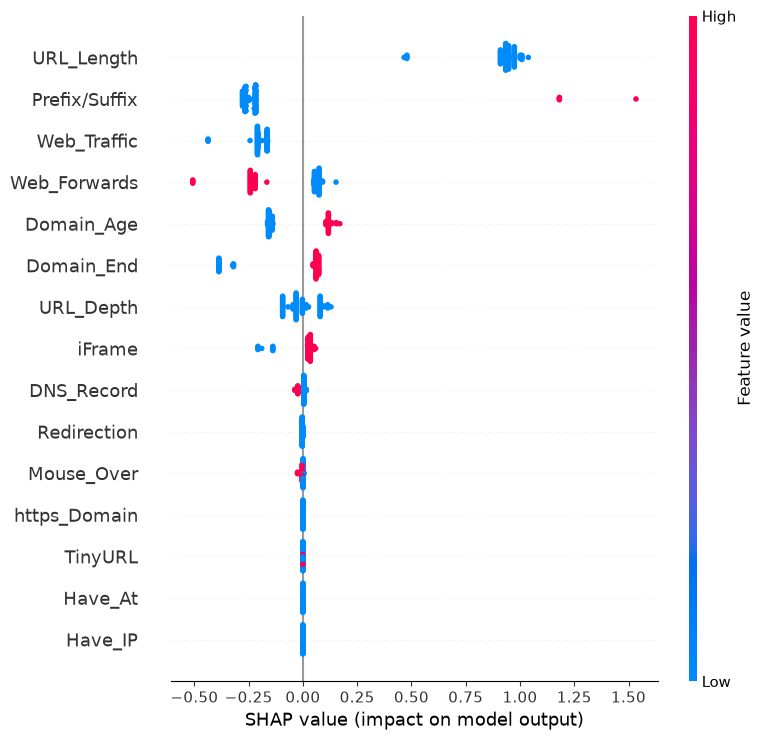

In [19]:
# ============================================================
# STEP 10J: SHAP ANALYSIS - AUGMENTED MODEL
# ============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer_aug = shap.TreeExplainer(
    tuned_xgb_aug
)

shap_values_aug = explainer_aug.shap_values(
    X_unseen_aug
)


# ============================================================
# GLOBAL SHAP IMPORTANCE
# ============================================================

shap_importance_aug = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "Mean_Abs_SHAP": np.abs(
        shap_values_aug
    ).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)


# ============================================================
# DISPLAY
# ============================================================

print(
    "========== AUGMENTED MODEL SHAP IMPORTANCE =========="
)

print(
    shap_importance_aug.to_string(
        index=False
    )
)


# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

plt.figure(
    figsize=(9, 7)
)

shap.summary_plot(
    shap_values_aug,
    X_unseen_aug,
    feature_names=FINAL_FEATURES,
    show=False
)

plt.tight_layout()

plt.show()

In [20]:
# ============================================================
# STEP 10K: ANALYZE UNSEEN FALSE POSITIVES
# ============================================================

analysis_df = validation_df[
    ["Domain"] + FINAL_FEATURES
].copy()

analysis_df["Predicted_Label"] = (
    y_unseen_pred_aug
)

analysis_df["Phishing_Probability"] = (
    y_unseen_prob_aug
)


# ============================================================
# FALSE POSITIVES ONLY
# ============================================================

false_positive_df = analysis_df[
    analysis_df["Predicted_Label"] == 1
].copy()


print(
    "========== FALSE POSITIVE ANALYSIS =========="
)

print(
    "\nFalse positives:",
    len(false_positive_df)
)

print(
    "Correct legitimate:",
    len(analysis_df)
    - len(false_positive_df)
)


# ============================================================
# FEATURE MEANS
# ============================================================

fp_feature_means = (
    false_positive_df[FINAL_FEATURES]
    .mean()
    .sort_values(
        ascending=False
    )
)


print(
    "\nFalse-positive feature means:"
)

print(
    fp_feature_means
)


# ============================================================
# FIRST 20 FALSE POSITIVES
# ============================================================

print(
    "\nFirst 20 false-positive URLs:"
)

print(
    false_positive_df[
        [
            "Domain",
            "URL_Length",
            "URL_Depth",
            "Prefix/Suffix",
            "Web_Traffic",
            "Domain_Age",
            "Domain_End",
            "iFrame",
            "Web_Forwards",
            "Phishing_Probability"
        ]
    ]
    .head(20)
    .to_string(index=False)
)

========== FALSE POSITIVE ANALYSIS ==========

False positives: 74
Correct legitimate: 26

False-positive feature means:
Web_Traffic      1.000000
Domain_End       1.000000
iFrame           0.932432
Web_Forwards     0.540541
Mouse_Over       0.527027
Domain_Age       0.391892
DNS_Record       0.324324
TinyURL          0.094595
Prefix/Suffix    0.067568
https_Domain     0.000000
Redirection      0.000000
Have_IP          0.000000
Have_At          0.000000
URL_Depth        0.000000
URL_Length       0.000000
dtype: float64

First 20 false-positive URLs:
           Domain  URL_Length  URL_Depth  Prefix/Suffix  Web_Traffic  Domain_Age  Domain_End  iFrame  Web_Forwards  Phishing_Probability
   cloudflare.com           0          0              0            1           0           1       1             0              0.615056
       akamai.net           0          0              0            1           1           1       1             1              0.625243
     facebook.com           0   

In [21]:
print(validation_df.columns.tolist())
print(validation_df.head())

['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']
           Domain  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  \
0  googleapis.com        0        0           0          0            0   
1  cloudflare.com        0        0           0          0            0   
2      akamai.net        0        0           0          0            0   
3     gstatic.com        0        0           0          0            0   
4    facebook.com        0        0           0          0            0   

   https_Domain  TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  Domain_Age  \
0             0        0              0           0            1           0   
1             0        0              0           0            1           0   
2             0        0              0           1            1     

In [22]:
# ============================================================
# STEP 11: FAST iFRAME DIAGNOSTIC
# ============================================================

print("========== iFRAME DIAGNOSTIC ==========")

print("\nOverall iFrame distribution:")
print(validation_df["iFrame"].value_counts())

print("\nFalse-positive iFrame distribution:")
print(
    false_positive_df["iFrame"]
    .value_counts()
)

print("\nFalse-positive iFrame = 1:")
print(
    (false_positive_df["iFrame"] == 1).sum()
)

print("\nFalse-positive iFrame = 0:")
print(
    (false_positive_df["iFrame"] == 0).sum()
)

========== iFRAME DIAGNOSTIC ==========

Overall iFrame distribution:
iFrame
1    90
0    10
Name: count, dtype: int64

False-positive iFrame distribution:
iFrame
1    69
0     5
Name: count, dtype: int64

False-positive iFrame = 1:
69

False-positive iFrame = 0:
5


In [23]:
# ============================================================
# STEP 12: iFRAME vs MODEL PREDICTION
# ============================================================

iframe_analysis = validation_df[
    ["Domain", "iFrame"]
].copy()

iframe_analysis["Predicted_Label"] = y_unseen_pred_aug
iframe_analysis["Phishing_Probability"] = y_unseen_prob_aug

print("========== iFRAME vs PREDICTION ==========")

print("\nPrediction by iFrame value:")

print(
    pd.crosstab(
        iframe_analysis["iFrame"],
        iframe_analysis["Predicted_Label"]
    )
)

print("\nMean phishing probability by iFrame:")

print(
    iframe_analysis
    .groupby("iFrame")["Phishing_Probability"]
    .mean()
)

print("\nDetailed summary:")

print(
    iframe_analysis
    .groupby("iFrame")
    .agg(
        Total=("Predicted_Label", "count"),
        Predicted_Legitimate=("Predicted_Label", lambda x: (x == 0).sum()),
        Predicted_Phishing=("Predicted_Label", lambda x: (x == 1).sum()),
        Mean_Probability=("Phishing_Probability", "mean")
    )
)

========== iFRAME vs PREDICTION ==========

Prediction by iFrame value:
Predicted_Label   0   1
iFrame                 
0                 5   5
1                21  69

Mean phishing probability by iFrame:
iFrame
0    0.540978
1    0.583953
Name: Phishing_Probability, dtype: float32

Detailed summary:
        Total  Predicted_Legitimate  Predicted_Phishing  Mean_Probability
iFrame                                                                   
0          10                     5                   5          0.540978
1          90                    21                  69          0.583953


In [24]:
# ============================================================
# STEP 13: ROOT-URL REPRESENTATION IN ORIGINAL 10K DATA
# ============================================================

root_url_analysis = df[
    ["Domain", "URL_Length", "URL_Depth", "Label"]
].copy()

root_url_analysis["Root_Representation"] = (
    (root_url_analysis["URL_Length"] == 0) &
    (root_url_analysis["URL_Depth"] == 0)
)

print("========== ROOT URL REPRESENTATION ==========")

print("\nOverall:")
print(
    root_url_analysis["Root_Representation"]
    .value_counts()
)

print("\nBy Label:")
print(
    pd.crosstab(
        root_url_analysis["Root_Representation"],
        root_url_analysis["Label"]
    )
)

print("\nRoot representation percentage by class:")

print(
    root_url_analysis
    .groupby("Label")["Root_Representation"]
    .mean()
    .mul(100)
)

========== ROOT URL REPRESENTATION ==========

Overall:
Root_Representation
False    8197
True     1803
Name: count, dtype: int64

By Label:
Label                   0     1
Root_Representation            
False                5000  3197
True                    0  1803

Root representation percentage by class:
Label
0     0.00
1    36.06
Name: Root_Representation, dtype: float64


In [25]:
# ============================================================
# STEP 14: ROOT REPRESENTATION IN AUGMENTED DATA
# ============================================================

augmentation_root = augmentation_df[
    ["Domain", "URL_Length", "URL_Depth", "Label"]
].copy()

augmentation_root["Root_Representation"] = (
    (augmentation_root["URL_Length"] == 0) &
    (augmentation_root["URL_Depth"] == 0)
)

print("========== AUGMENTATION ROOT REPRESENTATION ==========")

print("\nTotal augmentation samples:",
      len(augmentation_root))

print("\nRoot representation:")
print(
    augmentation_root["Root_Representation"]
    .value_counts()
)

print("\nBy Label:")
print(
    pd.crosstab(
        augmentation_root["Root_Representation"],
        augmentation_root["Label"]
    )
)

print("\nRoot representation percentage:")
print(
    augmentation_root["Root_Representation"]
    .mean() * 100
)

========== AUGMENTATION ROOT REPRESENTATION ==========

Total augmentation samples: 500

Root representation:
Root_Representation
True    500
Name: count, dtype: int64

By Label:
Label                  0
Root_Representation     
True                 500

Root representation percentage:
100.0


In [26]:
# ============================================================
# STEP 15: CHECK CURRENT MODEL
# ============================================================

print("Augmented model available:", "tuned_xgb_aug" in globals())

if "tuned_xgb_aug" in globals():
    print("Model type:", type(tuned_xgb_aug))
    print("Number of features:", tuned_xgb_aug.n_features_in_)

Augmented model available: True
Model type: <class 'xgboost.sklearn.XGBClassifier'>
Number of features: 15


In [27]:
# ============================================================
# STEP 16: FINAL UNSEEN VALIDATION METRICS
# ============================================================

X_unseen = prepare_features(validation_df)
y_unseen = validation_df["Label"]

y_unseen_pred = tuned_xgb_aug.predict(X_unseen)
y_unseen_prob = tuned_xgb_aug.predict_proba(X_unseen)[:, 1]

print("========== UNSEEN VALIDATION ==========")

print("Total samples:", len(X_unseen))
print("Legitimate:", (y_unseen == 0).sum())
print("Phishing:", (y_unseen == 1).sum())

print("\nAccuracy:",
      accuracy_score(y_unseen, y_unseen_pred))

print("Precision:",
      precision_score(y_unseen, y_unseen_pred, zero_division=0))

print("Recall:",
      recall_score(y_unseen, y_unseen_pred, zero_division=0))

print("F1:",
      f1_score(y_unseen, y_unseen_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_unseen, y_unseen_prob))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_unseen,
        y_unseen_pred
    )
)

========== UNSEEN VALIDATION ==========
Total samples: 100
Legitimate: 100
Phishing: 0

Accuracy: 0.26
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: nan

Confusion Matrix:
[[26 74]
 [ 0  0]]


c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [28]:
from src.features import url_features as uf
test_url = "https://www.google.com/"

features = uf.featureExtraction(test_url, 0)

test_df = pd.DataFrame(
    [features],
    columns=uf.feature_names
)

X_test_url = test_df[FINAL_FEATURES]

pred = tuned_xgb_aug.predict(X_test_url)[0]
prob = tuned_xgb_aug.predict_proba(X_test_url)[0][1]

print("URL:", test_url)
print("Prediction:", "Phishing" if pred == 1 else "Legitimate")
print("Phishing Probability:", prob)

Tranco domains loaded: 4384729
URL: https://www.google.com/
Prediction: Phishing
Phishing Probability: 0.61505634


In [29]:
# Google ke extracted features
google_features = pd.DataFrame(
    [features],
    columns=uf.feature_names
)

print("========== GOOGLE FEATURES ==========")
print(google_features[FINAL_FEATURES].T)

========== GOOGLE FEATURES ==========
               0
Have_IP        0
Have_At        0
URL_Length     0
URL_Depth      0
Redirection    0
https_Domain   0
TinyURL        0
Prefix/Suffix  0
DNS_Record     0
Web_Traffic    1
Domain_Age     0
Domain_End     1
iFrame         1
Mouse_Over     0
Web_Forwards   0


In [30]:
# Google ke feature pattern ko training data mein search karo

google_pattern = google_features[FINAL_FEATURES].iloc[0]

matches = (
    X_train_aug
    == google_pattern.values
).all(axis=1)

print("Exact matching training rows:", matches.sum())

if matches.sum() > 0:
    print("\nMatching labels:")
    print(y_train_aug[matches].value_counts())

Exact matching training rows: 332

Matching labels:
Label
1    216
0    116
Name: count, dtype: int64


In [31]:
pattern_stats = (
    pd.DataFrame({
        "Label": y_train_aug.values
    })
)

pattern_stats["Google_Pattern"] = matches.values

print(
    pattern_stats[
        pattern_stats["Google_Pattern"]
    ]["Label"].value_counts()
)

Label
1    216
0    116
Name: count, dtype: int64


In [32]:
google_pattern_rows = df_aug.loc[
    X_train_aug.index[matches],
    ["Domain", "Label"]
]

print(google_pattern_rows.head(30))

                                         Domain  Label
5022                      hbciverify.weebly.com      1
5039                townhallpro.myportfolio.com      1
5085                     noveltiesbk.weebly.com      1
5090                    rewsdhjkkjfd.weebly.com      1
5093          statementupdatemailbox.weebly.com      1
5116                votreligne.godaddysites.com      1
5121                     signinwebb0.weebly.com      1
5135           authenticatedbrtczimb.weebly.com      1
5138            jhdmhqwertyuikjvcxcv.weebly.com      1
5179      88xxzx8888888xz125654check.weebly.com      1
5180             eszterhazycellkabel.weebly.com      1
5246                    kundengmxnet.weebly.com      1
5255                          signdd.weebly.com      1
5305                   billingccways.weebly.com      1
5310     mailprijavabhtelecomwebmail.weebly.com      1
5311                metfmasktensnwlg.gitbook.io      1
5335                   start72.godaddysites.com      1
5390      

In [33]:
y_test_aug_prob = tuned_xgb_aug.predict_proba(X_test_aug)[:, 1]

print("Probability array created:", len(y_test_aug_prob))

Probability array created: 1972


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_results = []

for threshold in [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:

    y_pred_threshold = (
        y_test_aug_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test_aug, y_pred_threshold),
        "Precision": precision_score(
            y_test_aug,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_aug,
            y_pred_threshold,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_aug,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df)

   Threshold  Accuracy  Precision    Recall        F1
0       0.40  0.908215   0.860950  0.924129  0.891422
1       0.45  0.915314   0.877817  0.920398  0.898604
2       0.50  0.920892   0.892252  0.916667  0.904294
3       0.55  0.925456   0.904059  0.914179  0.909091
4       0.60  0.920892   0.913265  0.890547  0.901763
5       0.65  0.916329   0.974740  0.815920  0.888287
6       0.70  0.915822   0.976119  0.813433  0.887381
7       0.75  0.889452   0.993266  0.733831  0.844063
8       0.80  0.889452   0.993266  0.733831  0.844063


In [35]:
print(tranco.columns.tolist())
print(tranco.head())

['rank', 'domain']
   rank          domain
0     1      google.com
1     2  cloudflare.com
2     3    facebook.com
3     4     gstatic.com
4     5  googleapis.com


In [36]:
tranco_path = PROJECT_ROOT / "data" / "raw" / "tranco_GQJ9K.csv"

tranco = pd.read_csv(
    tranco_path,
    header=None,
    names=["rank", "domain"]
)

print("Tranco shape:", tranco.shape)
print(tranco.head())

Tranco shape: (4384729, 2)
   rank          domain
0     1      google.com
1     2  cloudflare.com
2     3    facebook.com
3     4     gstatic.com
4     5  googleapis.com


In [37]:
used_domains = set(
    df_aug["Domain"]
    .astype(str)
    .str.lower()
)

new_legit = tranco[
    ~tranco["domain"]
    .astype(str)
    .str.lower()
    .isin(used_domains)
].head(1000).copy()

new_legit["URL"] = (
    "https://" + new_legit["domain"].astype(str)
)

print("New legitimate domains selected:", len(new_legit))
print(new_legit.head(10))

New legitimate domains selected: 1000
    rank          domain                     URL
1      2  cloudflare.com  https://cloudflare.com
2      3    facebook.com    https://facebook.com
3      4     gstatic.com     https://gstatic.com
4      5  googleapis.com  https://googleapis.com
5      6   microsoft.com   https://microsoft.com
6      7   amazonaws.com   https://amazonaws.com
7      8      akamai.net      https://akamai.net
8      9     youtube.com     https://youtube.com
9     10       apple.com       https://apple.com
11    12         mail.ru         https://mail.ru


In [43]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import pandas as pd

# ============================================================
# STEP 17B: CHECKPOINT-BASED FEATURE EXTRACTION
# ============================================================

CHECKPOINT_DIR = PROJECT_ROOT / "data" / "validation" / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_FILE = (
    CHECKPOINT_DIR / "new_legitimate_1000_checkpoint.csv"
)

FINAL_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "new_legitimate_1000_features.csv"
)

BATCH_SIZE = 50
MAX_WORKERS = 5


def extract_one(url):
    try:
        return uf.featureExtraction(url, 0)
    except Exception as e:
        print(f"\nError: {url} -> {e}")
        return None


# ------------------------------------------------------------
# Load existing checkpoint if available
# ------------------------------------------------------------

if CHECKPOINT_FILE.exists():

    checkpoint_df = pd.read_csv(CHECKPOINT_FILE)

    print(
        "Existing checkpoint found:",
        checkpoint_df.shape
    )

else:

    checkpoint_df = pd.DataFrame(
        columns=uf.feature_names
    )

    print("No checkpoint found. Starting fresh.")


# ------------------------------------------------------------
# Determine already processed URLs
# ------------------------------------------------------------

processed_domains = set(
    checkpoint_df["Domain"]
    .astype(str)
    .str.lower()
)

remaining = new_legit[
    ~new_legit["domain"]
    .astype(str)
    .str.lower()
    .isin(processed_domains)
].copy()

print("Already processed:", len(checkpoint_df))
print("Remaining:", len(remaining))


# ------------------------------------------------------------
# Process in batches
# ------------------------------------------------------------

for start in range(0, len(remaining), BATCH_SIZE):

    batch = remaining.iloc[
        start:start + BATCH_SIZE
    ]

    batch_urls = batch["URL"].tolist()

    results = []

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:

        futures = {
            executor.submit(
                extract_one,
                url
            ): url
            for url in batch_urls
        }

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"Batch {start // BATCH_SIZE + 1}"
        ):

            result = future.result()

            if result is not None:
                results.append(result)


    # --------------------------------------------------------
    # Save checkpoint AFTER EVERY BATCH
    # --------------------------------------------------------

    if results:

        batch_df = pd.DataFrame(
            results,
            columns=uf.feature_names
        )

        checkpoint_df = pd.concat(
            [checkpoint_df, batch_df],
            ignore_index=True
        )

        checkpoint_df.to_csv(
            CHECKPOINT_FILE,
            index=False
        )

        print(
            f"\nCheckpoint saved: "
            f"{len(checkpoint_df)}/1000"
        )


# ------------------------------------------------------------
# Save final extracted dataset
# ------------------------------------------------------------

checkpoint_df.to_csv(
    FINAL_FILE,
    index=False
)

print("\n========== EXTRACTION COMPLETE ==========")
print("Final shape:", checkpoint_df.shape)
print("Missing values:", checkpoint_df.isna().sum().sum())
print("\nLabel counts:")
print(checkpoint_df["Label"].value_counts())

print("\nCheckpoint:")
print(CHECKPOINT_FILE)

print("\nFinal file:")
print(FINAL_FILE)

In [38]:
NEW_FEATURES_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "new_legitimate_1000_features.csv"
)

new_legitimate_1000_features = pd.read_csv(
    NEW_FEATURES_FILE
)

print("========== NEW LEGITIMATE DATA CHECK ==========")

print("Shape:", new_legitimate_1000_features.shape)

print(
    "Missing values:",
    new_legitimate_1000_features.isna().sum().sum()
)

print("\nLabel distribution:")
print(
    new_legitimate_1000_features["Label"].value_counts()
)

print(
    "\nDuplicate rows:",
    new_legitimate_1000_features.duplicated().sum()
)

========== NEW LEGITIMATE DATA CHECK ==========
Shape: (1000, 18)
Missing values: 0

Label distribution:
Label
0    1000
Name: count, dtype: int64

Duplicate rows: 0


In [39]:
# STEP 17D: Add 1000 new legitimate samples

combined_aug = pd.concat(
    [
        df_aug,
        new_legitimate_1000_features
    ],
    ignore_index=True
)

print("========== COMBINED DATASET ==========")
print("Shape:", combined_aug.shape)

print("\nLabel distribution:")
print(combined_aug["Label"].value_counts())

print("\nMissing values:")
print(combined_aug.isna().sum().sum())

========== COMBINED DATASET ==========
Shape: (11500, 18)

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64

Missing values:
0


In [40]:
from sklearn.model_selection import GroupShuffleSplit

FINAL_FEATURES = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards",
]

X_all = combined_aug[FINAL_FEATURES]
y_all = combined_aug["Label"]
groups = combined_aug["Domain"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X_all,
        y_all,
        groups=groups
    )
)

X_train_new = X_all.iloc[train_idx]
X_test_new = X_all.iloc[test_idx]

y_train_new = y_all.iloc[train_idx]
y_test_new = y_all.iloc[test_idx]

print("========== DOMAIN-AWARE SPLIT ==========")
print("X_train:", X_train_new.shape)
print("X_test :", X_test_new.shape)

print("\nTrain labels:")
print(y_train_new.value_counts())

print("\nTest labels:")
print(y_test_new.value_counts())

train_domains = set(
    groups.iloc[train_idx]
)

test_domains = set(
    groups.iloc[test_idx]
)

print("\nTrain domains:", len(train_domains))
print("Test domains :", len(test_domains))
print("Domain overlap:", len(train_domains & test_domains))

========== DOMAIN-AWARE SPLIT ==========
X_train: (9111, 15)
X_test : (2389, 15)

Train labels:
Label
0    5111
1    4000
Name: count, dtype: int64

Test labels:
Label
0    1389
1    1000
Name: count, dtype: int64

Train domains: 3953
Test domains : 989
Domain overlap: 0


In [41]:
# STEP 17E: Train XGBoost on 11,500-row dataset

from xgboost import XGBClassifier

tuned_xgb_final = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

tuned_xgb_final.fit(
    X_train_new,
    y_train_new
)

print("========== FINAL CANDIDATE TRAINED ==========")
print("Model:", type(tuned_xgb_final))
print("Features:", X_train_new.shape[1])
print("Training samples:", X_train_new.shape[0])

========== FINAL CANDIDATE TRAINED ==========
Model: <class 'xgboost.sklearn.XGBClassifier'>
Features: 15
Training samples: 9111


In [42]:
# STEP 17F: Evaluate final candidate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

y_pred_final = tuned_xgb_final.predict(X_test_new)
y_prob_final = tuned_xgb_final.predict_proba(X_test_new)[:, 1]

print("========== FINAL CANDIDATE TEST ==========")

print("Accuracy :", accuracy_score(y_test_new, y_pred_final))
print("Precision:", precision_score(y_test_new, y_pred_final, zero_division=0))
print("Recall   :", recall_score(y_test_new, y_pred_final, zero_division=0))
print("F1       :", f1_score(y_test_new, y_pred_final, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test_new, y_prob_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_new, y_pred_final))

========== FINAL CANDIDATE TEST ==========
Accuracy : 0.9183758894935119
Precision: 0.9890643985419199
Recall   : 0.814
F1       : 0.8930334613274822
ROC-AUC  : 0.9491490280777537

Confusion Matrix:
[[1380    9]
 [ 186  814]]


In [43]:
# STEP 17G-1: Extract Google features again

from src.features import url_features as uf

google_url = "https://www.google.com/"

google_features = pd.DataFrame(
    [uf.featureExtraction(google_url, 0)],
    columns=uf.feature_names
)

print("Google feature shape:", google_features.shape)
print(google_features)

Google feature shape: (1, 18)
       Domain  Have_IP  Have_At  URL_Length  URL_Depth  Redirection  \
0  google.com        0        0           0          0            0   

   https_Domain  TinyURL  Prefix/Suffix  DNS_Record  Web_Traffic  Domain_Age  \
0             0        0              0           0            1           0   

   Domain_End  iFrame  Mouse_Over  Right_Click  Web_Forwards  Label  
0           1       1           0            1             0      0  


In [44]:
# STEP 17G-2: Google real-world sanity check

google_pred = tuned_xgb_final.predict(
    google_features[FINAL_FEATURES]
)[0]

google_prob = tuned_xgb_final.predict_proba(
    google_features[FINAL_FEATURES]
)[0, 1]

print("========== GOOGLE TEST ==========")
print("URL: https://www.google.com/")
print(
    "Prediction:",
    "Phishing" if google_pred == 1 else "Legitimate"
)
print("Phishing Probability:", google_prob)

========== GOOGLE TEST ==========
URL: https://www.google.com/
Prediction: Legitimate
Phishing Probability: 0.3890301


In [45]:
# STEP 18: SHAP analysis for Google

import shap

google_X = google_features[FINAL_FEATURES]

explainer = shap.TreeExplainer(tuned_xgb_final)
google_shap = explainer(google_X)

shap_values = google_shap.values[0]

google_shap_df = pd.DataFrame({
    "Feature": FINAL_FEATURES,
    "SHAP": shap_values,
    "Abs_SHAP": abs(shap_values)
}).sort_values("Abs_SHAP", ascending=False)

print("========== GOOGLE SHAP ==========")
print(google_shap_df.to_string(index=False))

========== GOOGLE SHAP ==========
      Feature      SHAP  Abs_SHAP
Prefix/Suffix -0.329524  0.329524
   URL_Length  0.319474  0.319474
  Web_Traffic -0.227542  0.227542
    URL_Depth -0.090083  0.090083
   Domain_Age -0.087116  0.087116
   Domain_End  0.068536  0.068536
       iFrame  0.064792  0.064792
 Web_Forwards  0.062169  0.062169
   DNS_Record  0.007260  0.007260
   Mouse_Over  0.001523  0.001523
      Have_At -0.000077  0.000077
      TinyURL  0.000000  0.000000
 https_Domain  0.000000  0.000000
  Redirection  0.000000  0.000000
      Have_IP  0.000000  0.000000


In [46]:
# STEP 19: URL_Length diagnostic

url_length_analysis = (
    combined_aug
    .groupby(["URL_Length", "Label"])
    .size()
    .unstack(fill_value=0)
)

url_length_analysis.columns = ["Legitimate", "Phishing"]

print("========== URL LENGTH ANALYSIS ==========")
print(url_length_analysis)

print("\n========== URL LENGTH = 0 ==========")
print(
    combined_aug[
        combined_aug["URL_Length"] == 0
    ]["Label"].value_counts().rename(
        index={0: "Legitimate", 1: "Phishing"}
    )
)

========== URL LENGTH ANALYSIS ==========
            Legitimate  Phishing
URL_Length                      
0                 1500      3757
1                 5000      1243

========== URL LENGTH = 0 ==========
Label
Phishing      3757
Legitimate    1500
Name: count, dtype: int64


In [47]:
# STEP 20: Root URL representation analysis

root_url_analysis = (
    combined_aug
    .groupby(["URL_Length", "URL_Depth", "Label"])
    .size()
    .reset_index(name="Count")
)

print("========== ROOT URL REPRESENTATION ==========")

print(
    root_url_analysis[
        (root_url_analysis["URL_Length"] == 0) &
        (root_url_analysis["URL_Depth"] == 0)
    ].to_string(index=False)
)

========== ROOT URL REPRESENTATION ==========
 URL_Length  URL_Depth  Label  Count
          0          0      0   1500
          0          0      1   1803


In [48]:
# STEP 21: Compare features for root-level URLs

root_urls = combined_aug[
    (combined_aug["URL_Length"] == 0) &
    (combined_aug["URL_Depth"] == 0)
].copy()

root_feature_comparison = (
    root_urls
    .groupby("Label")[FINAL_FEATURES]
    .mean()
    .T
)

root_feature_comparison.columns = ["Legitimate", "Phishing"]

root_feature_comparison["Difference"] = (
    root_feature_comparison["Phishing"]
    - root_feature_comparison["Legitimate"]
)

print("========== ROOT URL FEATURE COMPARISON ==========")
print(
    root_feature_comparison
    .sort_values("Difference", key=abs, ascending=False)
    .to_string()
)

========== ROOT URL FEATURE COMPARISON ==========
               Legitimate  Phishing  Difference
Prefix/Suffix    0.068667  0.475874    0.407207
Domain_Age       0.279333  0.679978    0.400644
Web_Traffic      0.998000  0.632834   -0.365166
Domain_End       0.808000  0.957293    0.149293
iFrame           0.850000  0.982806    0.132806
DNS_Record       0.190000  0.242928    0.052928
Web_Forwards     0.345333  0.307266   -0.038068
TinyURL          0.059333  0.027732   -0.031602
Mouse_Over       0.330000  0.307266   -0.022734
Redirection      0.000000  0.002773    0.002773
https_Domain     0.000000  0.000555    0.000555
URL_Depth        0.000000  0.000000    0.000000
Have_IP          0.000000  0.000000    0.000000
Have_At          0.000000  0.000000    0.000000
URL_Length       0.000000  0.000000    0.000000


In [49]:
# STEP 22: Test model without URL_Length

FEATURES_NO_URL_LENGTH = [
    f for f in FINAL_FEATURES
    if f != "URL_Length"
]

xgb_no_url_length = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_no_url_length.fit(
    X_train_new[FEATURES_NO_URL_LENGTH],
    y_train_new
)

y_pred_no_url = xgb_no_url_length.predict(
    X_test_new[FEATURES_NO_URL_LENGTH]
)

y_prob_no_url = xgb_no_url_length.predict_proba(
    X_test_new[FEATURES_NO_URL_LENGTH]
)[:, 1]

print("========== WITHOUT URL_LENGTH ==========")
print("Accuracy :", accuracy_score(y_test_new, y_pred_no_url))
print("Precision:", precision_score(y_test_new, y_pred_no_url))
print("Recall   :", recall_score(y_test_new, y_pred_no_url))
print("F1       :", f1_score(y_test_new, y_pred_no_url))
print("ROC-AUC  :", roc_auc_score(y_test_new, y_prob_no_url))

google_pred_no_url = xgb_no_url_length.predict(
    google_features[FEATURES_NO_URL_LENGTH]
)[0]

google_prob_no_url = xgb_no_url_length.predict_proba(
    google_features[FEATURES_NO_URL_LENGTH]
)[0, 1]

print("\n========== GOOGLE WITHOUT URL_LENGTH ==========")
print(
    "Prediction:",
    "Phishing" if google_pred_no_url == 1 else "Legitimate"
)
print("Phishing Probability:", google_prob_no_url)

========== WITHOUT URL_LENGTH ==========
Accuracy : 0.8501465048137296
Precision: 0.8504366812227074
Recall   : 0.779
F1       : 0.8131524008350731
ROC-AUC  : 0.928744060475162

========== GOOGLE WITHOUT URL_LENGTH ==========
Prediction: Legitimate
Phishing Probability: 0.38993096


In [50]:
# STEP 22: Famous legitimate URL sanity check

famous_urls = [
    "https://www.google.com/",
    "https://www.github.com/",
    "https://www.microsoft.com/",
    "https://www.youtube.com/",
    "https://www.apple.com/"
]

famous_results = []

for url in famous_urls:
    features = pd.DataFrame(
        [uf.featureExtraction(url, 0)],
        columns=uf.feature_names
    )

    pred = tuned_xgb_final.predict(
        features[FINAL_FEATURES]
    )[0]

    prob = tuned_xgb_final.predict_proba(
        features[FINAL_FEATURES]
    )[0, 1]

    famous_results.append({
        "URL": url,
        "Prediction": "Phishing" if pred == 1 else "Legitimate",
        "Phishing_Probability": prob
    })

famous_results_df = pd.DataFrame(famous_results)

print("========== FAMOUS URL SANITY CHECK ==========")
print(famous_results_df.to_string(index=False))

========== FAMOUS URL SANITY CHECK ==========
                       URL Prediction  Phishing_Probability
   https://www.google.com/ Legitimate              0.389030
   https://www.github.com/ Legitimate              0.389030
https://www.microsoft.com/ Legitimate              0.389030
  https://www.youtube.com/ Legitimate              0.272913
    https://www.apple.com/ Legitimate              0.263850


In [52]:
# STEP 23A: Load current 11,500-row dataset

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x"
)

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_augmented.csv"
)

print("Dataset path:")
print(DATA_FILE)

print("\nFile exists:", DATA_FILE.exists())

df_compare = pd.read_csv(DATA_FILE)

print("\n========== DATASET ==========")
print("Shape:", df_compare.shape)

print("\nLabel distribution:")
print(df_compare["Label"].value_counts())

Dataset path:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\phishguard_features_augmented.csv

File exists: True

========== DATASET ==========
Shape: (10500, 18)

Label distribution:
Label
0    5500
1    5000
Name: count, dtype: int64


In [53]:
# ============================================================
# STEP 23B: CREATE 11,500-ROW FINAL CANDIDATE DATASET
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 1. Project path
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x"
)

# ------------------------------------------------------------
# 2. Input files
# ------------------------------------------------------------

BASE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_augmented.csv"
)

NEW_LEGIT_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "new_legitimate_1000_features.csv"
)

# ------------------------------------------------------------
# 3. Load both datasets
# ------------------------------------------------------------

base_df = pd.read_csv(BASE_FILE)
new_legit_df = pd.read_csv(NEW_LEGIT_FILE)

print("========== INPUT DATASETS ==========")
print("Base dataset:", base_df.shape)
print("New legitimate:", new_legit_df.shape)

print("\nBase labels:")
print(base_df["Label"].value_counts())

print("\nNew legitimate labels:")
print(new_legit_df["Label"].value_counts())

# ------------------------------------------------------------
# 4. Combine
# ------------------------------------------------------------

final_candidate_df = pd.concat(
    [base_df, new_legit_df],
    ignore_index=True
)

# ------------------------------------------------------------
# 5. Remove accidental exact duplicates, if any
#    (Only duplicates created by the merge itself)
# ------------------------------------------------------------

before_duplicates = len(final_candidate_df)

final_candidate_df = final_candidate_df.drop_duplicates(
    keep="first"
).reset_index(drop=True)

after_duplicates = len(final_candidate_df)

# ------------------------------------------------------------
# 6. Save new final candidate dataset
# ------------------------------------------------------------

FINAL_DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_final_11500.csv"
)

final_candidate_df.to_csv(
    FINAL_DATA_FILE,
    index=False
)

# ------------------------------------------------------------
# 7. Verification
# ------------------------------------------------------------

print("\n========== FINAL CANDIDATE DATASET ==========")
print("File:", FINAL_DATA_FILE)
print("Shape:", final_candidate_df.shape)

print("\nLabel distribution:")
print(final_candidate_df["Label"].value_counts())

print("\nMissing values:", final_candidate_df.isna().sum().sum())

print("\nDuplicates removed during merge:", 
      before_duplicates - after_duplicates)

print("\nFile exists:", FINAL_DATA_FILE.exists())

========== INPUT DATASETS ==========
Base dataset: (10500, 18)
New legitimate: (1000, 18)

Base labels:
Label
0    5500
1    5000
Name: count, dtype: int64

New legitimate labels:
Label
0    1000
Name: count, dtype: int64

========== FINAL CANDIDATE DATASET ==========
File: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\phishguard_features_final_11500.csv
Shape: (5330, 18)

Label distribution:
Label
1    3277
0    2053
Name: count, dtype: int64

Missing values: 0

Duplicates removed during merge: 6170

File exists: True


In [54]:
# ============================================================
# STEP 23C: CREATE CORRECT 11,500-ROW DATASET
# IMPORTANT: DO NOT REMOVE DUPLICATES
# ============================================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x"
)

BASE_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_augmented.csv"
)

NEW_LEGIT_FILE = (
    PROJECT_ROOT
    / "data"
    / "validation"
    / "new_legitimate_1000_features.csv"
)

FINAL_DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_final_11500.csv"
)

# Load
base_df = pd.read_csv(BASE_FILE)
new_legit_df = pd.read_csv(NEW_LEGIT_FILE)

# Combine WITHOUT removing duplicates
final_candidate_df = pd.concat(
    [base_df, new_legit_df],
    ignore_index=True
)

# Save
final_candidate_df.to_csv(
    FINAL_DATA_FILE,
    index=False
)

# Verification
print("========== CORRECT FINAL CANDIDATE DATASET ==========")
print("File:", FINAL_DATA_FILE)
print("Shape:", final_candidate_df.shape)

print("\nLabel distribution:")
print(final_candidate_df["Label"].value_counts())

print("\nMissing values:")
print(final_candidate_df.isna().sum().sum())

print("\nDuplicate rows:")
print(final_candidate_df.duplicated().sum())

print("\nFile exists:")
print(FINAL_DATA_FILE.exists())

========== CORRECT FINAL CANDIDATE DATASET ==========
File: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\phishguard_features_final_11500.csv
Shape: (11500, 18)

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
6170

File exists:
True


In [55]:
# STEP 24: FAIR MODEL COMPARISON ON CORRECT 11,500-ROW DATASET

from pathlib import Path

import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. PATH
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x"
)

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_final_11500.csv"
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

print("========== DATASET ==========")
print("File:", DATA_FILE)
print("Shape:", df.shape)

print("\nLabel distribution:")
print(df["Label"].value_counts())

print("\nMissing values:")
print(df.isna().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


# ============================================================
# 3. FINAL MODEL FEATURES
# ============================================================

FINAL_FEATURES_COMPARE = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]

X = df[FINAL_FEATURES_COMPARE].copy()
y = df["Label"].copy()

groups = df["Domain"].astype(str)


# ============================================================
# 4. DOMAIN-AWARE TRAIN/TEST SPLIT
# ============================================================

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]


print("\n========== DOMAIN-AWARE SPLIT ==========")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

train_domains = set(groups_train)
test_domains = set(groups_test)

print("\nTraining domains:", len(train_domains))
print("Testing domains :", len(test_domains))

print(
    "Domain overlap:",
    len(train_domains.intersection(test_domains))
)


# ============================================================
# 5. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]),

    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Tuned XGBoost": XGBClassifier(
        colsample_bytree=1.0,
        learning_rate=0.03,
        max_depth=3,
        n_estimators=100,
        subsample=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


# ============================================================
# 6. EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_score
        )
    }

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    return results, cm


# ============================================================
# 7. TRAIN + EVALUATE ALL MODELS
# ============================================================

all_results = []
confusion_matrices = {}

print("\n========== MODEL COMPARISON ==========")

for model_name, model in models.items():

    print(f"\nRunning: {model_name}")

    results, cm = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["Model"] = model_name

    all_results.append(results)

    confusion_matrices[model_name] = cm

    print(
        f"Accuracy : {results['Accuracy']:.4f}"
    )

    print(
        f"Precision: {results['Precision']:.4f}"
    )

    print(
        f"Recall   : {results['Recall']:.4f}"
    )

    print(
        f"F1       : {results['F1']:.4f}"
    )

    print(
        f"ROC-AUC  : {results['ROC-AUC']:.4f}"
    )


# ============================================================
# 8. COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(
    all_results
)

comparison_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
]

comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


print("\n\n========== FINAL COMPARISON ==========")

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# 9. CONFUSION MATRICES
# ============================================================

print("\n\n========== CONFUSION MATRICES ==========")

for model_name, cm in confusion_matrices.items():

    print(f"\n{model_name}")

    print(cm)


# ============================================================
# 10. BEST MODEL BY F1
# ============================================================

best_model = comparison_df.iloc[0]

print("\n\n========== BEST MODEL BY F1 ==========")

print("Model:", best_model["Model"])
print(f"F1: {best_model['F1']:.4f}")
print(f"ROC-AUC: {best_model['ROC-AUC']:.4f}")
print(f"Accuracy: {best_model['Accuracy']:.4f}")
print(f"Precision: {best_model['Precision']:.4f}")
print(f"Recall: {best_model['Recall']:.4f}")

========== DATASET ==========
File: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\data\processed\phishguard_features_final_11500.csv
Shape: (11500, 18)

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
6170

========== DOMAIN-AWARE SPLIT ==========
X_train: (9111, 15)
X_test : (2389, 15)

Training labels:
Label
0    5111
1    4000
Name: count, dtype: int64

Testing labels:
Label
0    1389
1    1000
Name: count, dtype: int64

Training domains: 3953
Testing domains : 989
Domain overlap: 0

========== MODEL COMPARISON ==========

Running: Logistic Regression
Accuracy : 0.8757
Precision: 0.8240
Recall   : 0.8940
F1       : 0.8576
ROC-AUC  : 0.9105

Running: KNN
Accuracy : 0.8397
Precision: 0.7454
Recall   : 0.9370
F1       : 0.8303
ROC-AUC  : 0.8795

Running: SVM RBF


c:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.8062
Precision: 0.8604
Recall   : 0.6410
F1       : 0.7347
ROC-AUC  : 0.9220

Running: Decision Tree
Accuracy : 0.9008
Precision: 0.8921
Recall   : 0.8680
F1       : 0.8799
ROC-AUC  : 0.9586

Running: Random Forest
Accuracy : 0.8853
Precision: 0.8616
Recall   : 0.8650
F1       : 0.8633
ROC-AUC  : 0.9568

Running: XGBoost
Accuracy : 0.8472
Precision: 0.7900
Recall   : 0.8650
F1       : 0.8258
ROC-AUC  : 0.9560

Running: Tuned XGBoost
Accuracy : 0.9184
Precision: 0.9891
Recall   : 0.8140
F1       : 0.8930
ROC-AUC  : 0.9491


========== FINAL COMPARISON ==========
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Tuned XGBoost    0.9184     0.9891  0.8140 0.8930   0.9491
      Decision Tree    0.9008     0.8921  0.8680 0.8799   0.9586
      Random Forest    0.8853     0.8616  0.8650 0.8633   0.9568
Logistic Regression    0.8757     0.8240  0.8940 0.8576   0.9105
                KNN    0.8397     0.7454  0.9370 0.8303   0.8795
            XGBoost    0.8472

In [56]:
# STEP 25: THRESHOLD ANALYSIS FOR TUNED XGBOOST

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Train Tuned XGBoost
# ------------------------------------------------------------

tuned_xgb_threshold = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

tuned_xgb_threshold.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 2. Get phishing probabilities
# ------------------------------------------------------------

y_prob = tuned_xgb_threshold.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 3. Test multiple thresholds
# ------------------------------------------------------------

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

threshold_results = []

print("========== THRESHOLD ANALYSIS ==========")

for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print(
        f"\nThreshold: {threshold:.2f}"
    )
    print(
        f"Accuracy : {accuracy:.4f}"
    )
    print(
        f"Precision: {precision:.4f}"
    )
    print(
        f"Recall   : {recall:.4f}"
    )
    print(
        f"F1       : {f1:.4f}"
    )


# ------------------------------------------------------------
# 4. Create comparison table
# ------------------------------------------------------------

threshold_df = pd.DataFrame(
    threshold_results
)

print("\n\n========== THRESHOLD COMPARISON ==========")

print(
    threshold_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ------------------------------------------------------------
# 5. Best threshold by F1
# ------------------------------------------------------------

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("\n\n========== BEST THRESHOLD BY F1 ==========")

print(
    "Threshold:",
    best_threshold_row["Threshold"]
)

print(
    f"Accuracy : {best_threshold_row['Accuracy']:.4f}"
)

print(
    f"Precision: {best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall   : {best_threshold_row['Recall']:.4f}"
)

print(
    f"F1       : {best_threshold_row['F1']:.4f}"
)


# ------------------------------------------------------------
# 6. Confusion matrix for best threshold
# ------------------------------------------------------------

best_threshold = best_threshold_row["Threshold"]

y_pred_best = (
    y_prob >= best_threshold
).astype(int)

best_cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("\n\n========== CONFUSION MATRIX ==========")

print(best_cm)

========== THRESHOLD ANALYSIS ==========

Threshold: 0.30
Accuracy : 0.8472
Precision: 0.7554
Recall   : 0.9390
F1       : 0.8373

Threshold: 0.35
Accuracy : 0.8602
Precision: 0.7770
Recall   : 0.9340
F1       : 0.8483

Threshold: 0.40
Accuracy : 0.8941
Precision: 0.8815
Recall   : 0.8630
F1       : 0.8722

Threshold: 0.45
Accuracy : 0.9071
Precision: 0.9138
Recall   : 0.8590
F1       : 0.8856

Threshold: 0.50
Accuracy : 0.9184
Precision: 0.9891
Recall   : 0.8140
F1       : 0.8930

Threshold: 0.55
Accuracy : 0.9180
Precision: 0.9902
Recall   : 0.8120
F1       : 0.8923

Threshold: 0.60
Accuracy : 0.9092
Precision: 0.9912
Recall   : 0.7900
F1       : 0.8792

Threshold: 0.65
Accuracy : 0.9087
Precision: 0.9924
Recall   : 0.7880
F1       : 0.8785

Threshold: 0.70
Accuracy : 0.9079
Precision: 0.9924
Recall   : 0.7860
F1       : 0.8772


========== THRESHOLD COMPARISON ==========
 Threshold  Accuracy  Precision  Recall     F1
    0.3000    0.8472     0.7554  0.9390 0.8373
    0.3500    0.860

In [57]:
# STEP 26: 5% FEATURE PERTURBATION ROBUSTNESS TEST

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. Train the same tuned XGBoost model
# ============================================================

robust_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

robust_model.fit(
    X_train,
    y_train
)


# ============================================================
# 2. Create a copy of test data
# ============================================================

X_test_perturbed = X_test.copy()


# ============================================================
# 3. Binary features to perturb
# ============================================================

BINARY_FEATURES = [
    "Have_IP",
    "Have_At",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]


# ============================================================
# 4. Randomly flip 5% of binary feature values
# ============================================================

rng = np.random.default_rng(42)

total_cells = (
    X_test_perturbed.shape[0]
    * len(BINARY_FEATURES)
)

n_flips = int(
    total_cells * 0.05
)

rows = rng.integers(
    0,
    X_test_perturbed.shape[0],
    size=n_flips
)

cols = rng.integers(
    0,
    len(BINARY_FEATURES),
    size=n_flips
)


for row, col in zip(rows, cols):

    feature = BINARY_FEATURES[col]

    X_test_perturbed.iloc[
        row,
        X_test_perturbed.columns.get_loc(feature)
    ] = 1 - X_test_perturbed.iloc[
        row,
        X_test_perturbed.columns.get_loc(feature)
    ]


print("========== PERTURBATION ==========")

print("Binary features:", len(BINARY_FEATURES))

print("Total test cells:",
      total_cells)

print("Cells flipped:",
      n_flips)

print("Perturbation rate:",
      f"{(n_flips / total_cells) * 100:.2f}%"
)


# ============================================================
# 5. Predict perturbed test data
# ============================================================

y_pred_perturbed = robust_model.predict(
    X_test_perturbed
)

y_prob_perturbed = robust_model.predict_proba(
    X_test_perturbed
)[:, 1]


# ============================================================
# 6. Evaluate
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred_perturbed
)

precision = precision_score(
    y_test,
    y_pred_perturbed,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_perturbed,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_perturbed,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_perturbed
)

cm = confusion_matrix(
    y_test,
    y_pred_perturbed
)


# ============================================================
# 7. Results
# ============================================================

print("\n========== 5% PERTURBATION RESULTS ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

========== PERTURBATION ==========
Binary features: 13
Total test cells: 31057
Cells flipped: 1552
Perturbation rate: 5.00%

========== 5% PERTURBATION RESULTS ==========
Accuracy : 0.8824
Precision: 0.9044
Recall   : 0.8040
F1       : 0.8512
ROC-AUC  : 0.9292

Confusion Matrix:
[[1304   85]
 [ 196  804]]


In [58]:
# STEP 27: 10% FEATURE NOISE ROBUSTNESS TEST

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# 1. Train the same tuned XGBoost model
# ============================================================

noise_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.03,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    eval_metric="logloss"
)

noise_model.fit(
    X_train,
    y_train
)


# ============================================================
# 2. Copy test data
# ============================================================

X_test_noisy = X_test.copy()


# ============================================================
# 3. Binary features
# ============================================================

BINARY_FEATURES = [
    "Have_IP",
    "Have_At",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]


# ============================================================
# 4. Apply 10% random feature noise
# ============================================================

rng = np.random.default_rng(42)

total_cells = (
    X_test_noisy.shape[0]
    * len(BINARY_FEATURES)
)

n_flips = int(
    total_cells * 0.10
)

rows = rng.integers(
    0,
    X_test_noisy.shape[0],
    size=n_flips
)

cols = rng.integers(
    0,
    len(BINARY_FEATURES),
    size=n_flips
)


for row, col in zip(rows, cols):

    feature = BINARY_FEATURES[col]

    current_value = X_test_noisy.iloc[
        row,
        X_test_noisy.columns.get_loc(feature)
    ]

    X_test_noisy.iloc[
        row,
        X_test_noisy.columns.get_loc(feature)
    ] = 1 - current_value


print("========== 10% FEATURE NOISE ==========")

print("Binary features:", len(BINARY_FEATURES))

print("Total test cells:", total_cells)

print("Cells flipped:", n_flips)

print(
    "Noise rate:",
    f"{(n_flips / total_cells) * 100:.2f}%"
)


# ============================================================
# 5. Predictions
# ============================================================

y_pred_noisy = noise_model.predict(
    X_test_noisy
)

y_prob_noisy = noise_model.predict_proba(
    X_test_noisy
)[:, 1]


# ============================================================
# 6. Metrics
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred_noisy
)

precision = precision_score(
    y_test,
    y_pred_noisy,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_noisy,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_noisy,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_noisy
)

cm = confusion_matrix(
    y_test,
    y_pred_noisy
)


# ============================================================
# 7. Final output
# ============================================================

print("\n========== 10% NOISE RESULTS ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(cm)

========== 10% FEATURE NOISE ==========
Binary features: 13
Total test cells: 31057
Cells flipped: 3105
Noise rate: 10.00%

========== 10% NOISE RESULTS ==========
Accuracy : 0.8661
Precision: 0.8688
Recall   : 0.8010
F1       : 0.8335
ROC-AUC  : 0.9216

Confusion Matrix:
[[1268  121]
 [ 199  801]]


In [51]:
# ============================================================
# STEP 23: FAIR MODEL COMPARISON
# Dataset:
# data/processed/phishguard_features_augmented.csv
#
# Dataset size: 11,500 rows
# Legitimate: 6,500
# Phishing: 5,000
# Evaluation: Domain-aware train/test split
# ============================================================

import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import f1_score, roc_auc_score

from xgboost import XGBClassifier


# ============================================================
# 1. LOAD FINAL CURRENT DATASET
# ============================================================

DATA_FILE = "data/processed/phishguard_features_augmented.csv"

df_compare = pd.read_csv(DATA_FILE)

print("========== DATASET ==========")
print("File:", DATA_FILE)
print("Shape:", df_compare.shape)
print("\nLabel distribution:")
print(df_compare["Label"].value_counts())


# ============================================================
# 2. FINAL FEATURES
# ============================================================

FINAL_FEATURES_COMPARE = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards",
]


# ============================================================
# 3. PREPARE X, y AND DOMAIN GROUPS
# ============================================================

X_all_compare = df_compare[FINAL_FEATURES_COMPARE].copy()
y_all_compare = df_compare["Label"].copy()
groups_compare = df_compare["Domain"].astype(str).str.lower()


# ============================================================
# 4. DOMAIN-AWARE TRAIN/TEST SPLIT
# ============================================================

gss_compare = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_compare, test_idx_compare = next(
    gss_compare.split(
        X_all_compare,
        y_all_compare,
        groups=groups_compare
    )
)

X_train_compare = X_all_compare.iloc[train_idx_compare]
X_test_compare = X_all_compare.iloc[test_idx_compare]

y_train_compare = y_all_compare.iloc[train_idx_compare]
y_test_compare = y_all_compare.iloc[test_idx_compare]

train_domains_compare = groups_compare.iloc[train_idx_compare]
test_domains_compare = groups_compare.iloc[test_idx_compare]


# ============================================================
# 5. VERIFY DOMAIN SEPARATION
# ============================================================

domain_overlap_compare = set(
    train_domains_compare
).intersection(
    set(test_domains_compare)
)

print("\n========== DOMAIN-AWARE SPLIT ==========")
print("X_train:", X_train_compare.shape)
print("X_test :", X_test_compare.shape)

print("\nTrain labels:")
print(y_train_compare.value_counts())

print("\nTest labels:")
print(y_test_compare.value_counts())

print("\nTrain domains:", train_domains_compare.nunique())
print("Test domains :", test_domains_compare.nunique())
print("Domain overlap:", len(domain_overlap_compare))


# ============================================================
# 6. SCALE FEATURES FOR LINEAR/DISTANCE MODELS
# ============================================================

scaler_compare = StandardScaler()

X_train_scaled_compare = scaler_compare.fit_transform(
    X_train_compare
)

X_test_scaled_compare = scaler_compare.transform(
    X_test_compare
)


# ============================================================
# 7. DEFINE MODELS
# ============================================================

models_compare = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Tuned XGBoost": XGBClassifier(
        colsample_bytree=1.0,
        learning_rate=0.03,
        max_depth=3,
        n_estimators=100,
        subsample=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}


# ============================================================
# 8. TRAIN + EVALUATE ALL MODELS
# ============================================================

comparison_results = []

for model_name, model in models_compare.items():

    print(f"\nTraining: {model_name}")

    # Tree-based models do not require scaling
    if model_name in [
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ]:

        model.fit(
            X_train_compare,
            y_train_compare
        )

        y_pred = model.predict(
            X_test_compare
        )

        y_prob = model.predict_proba(
            X_test_compare
        )[:, 1]

    # Logistic Regression, KNN and SVM use scaled data
    else:

        model.fit(
            X_train_scaled_compare,
            y_train_compare
        )

        y_pred = model.predict(
            X_test_scaled_compare
        )

        y_prob = model.predict_proba(
            X_test_scaled_compare
        )[:, 1]


    f1 = f1_score(
        y_test_compare,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_compare,
        y_prob
    )

    comparison_results.append({
        "Model": model_name,
        "F1": f1,
        "ROC-AUC": roc_auc
    })


# ============================================================
# 9. CREATE COMPARISON TABLE
# ============================================================

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 10. DISPLAY FINAL COMPARISON
# ============================================================

print("\n\n================================================")
print("FINAL MODEL COMPARISON")
print("Dataset: phishguard_features_augmented.csv")
print("Evaluation: Domain-aware 80/20 split")
print("================================================")

print(
    comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/phishguard_features_augmented.csv'

In [35]:
# STEP 17G: Google real-world sanity check

google_pred = tuned_xgb_final.predict(
    google_features[FINAL_FEATURES]
)[0]

google_prob = tuned_xgb_final.predict_proba(
    google_features[FINAL_FEATURES]
)[0, 1]

print("========== GOOGLE TEST ==========")
print("URL: https://www.google.com/")
print(
    "Prediction:",
    "Phishing" if google_pred == 1 else "Legitimate"
)
print("Phishing Probability:", google_prob)

NameError: name 'google_features' is not defined

In [44]:
print("========== NEW LEGITIMATE DATA CHECK ==========")

print("Shape:", new_legitimate_1000_features.shape)

print("\nMissing values:")
print(
    new_legitimate_1000_features.isna().sum().sum()
)

print("\nLabel distribution:")
print(
    new_legitimate_1000_features["Label"].value_counts()
)

print("\nDuplicate rows:")
print(
    new_legitimate_1000_features.duplicated().sum()
)

print("\nSample:")
display(
    new_legitimate_1000_features.head()
)

NameError: name 'new_legitimate_1000_features' is not defined

In [38]:
# STEP 17A: Select 1000 NEW legitimate domains

tranco_path = PROJECT_ROOT / "data" / "raw" / "tranco_GQJ9K.csv"

tranco = pd.read_csv(tranco_path)

print("Tranco shape:", tranco.shape)
print("Columns:", tranco.columns.tolist())

# Original + existing augmentation domains ko exclude karo
used_domains = set(
    df_aug["Domain"].astype(str).str.lower()
)

new_legit = tranco[
    ~tranco["domain"].astype(str).str.lower().isin(used_domains)
].head(1000).copy()

new_legit["URL"] = (
    "https://" + new_legit["domain"].astype(str)
)

print("New legitimate domains selected:", len(new_legit))
print(new_legit.head(10))

Tranco shape: (4384728, 2)
Columns: ['1', 'google.com']


KeyError: 'domain'

In [26]:
# ============================================================
# STEP 15: COMPARE ORIGINAL VS AUGMENTED MODEL
# ============================================================

# Original tuned model
original_model = joblib.load(
    PROJECT_ROOT / "models" / "tuned_xgboost.joblib"
)

# Augmented model is already trained as:
# tuned_xgb_aug

# Prepare unseen validation features
X_unseen = prepare_features(validation_df)
y_unseen = validation_df["Label"]

# Original model prediction
original_pred = original_model.predict(X_unseen)
original_prob = original_model.predict_proba(X_unseen)[:, 1]

# Augmented model prediction
aug_pred = tuned_xgb_aug.predict(X_unseen)
aug_prob = tuned_xgb_aug.predict_proba(X_unseen)[:, 1]

print("========== MODEL COMPARISON ==========")

print("\nOriginal Tuned XGBoost:")
print("Correct legitimate:", (original_pred == 0).sum())
print("False positives:", (original_pred == 1).sum())
print("Mean phishing probability:", original_prob.mean())

print("\nAugmented Tuned XGBoost:")
print("Correct legitimate:", (aug_pred == 0).sum())
print("False positives:", (aug_pred == 1).sum())
print("Mean phishing probability:", aug_prob.mean())

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\nk134\\OneDrive\\Desktop\\coding\\phishguard-x\\models\\tuned_xgboost.joblib'

In [2]:
from pathlib import Path
import sys
import joblib
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

MODEL_PATH = PROJECT_ROOT / "models" / "tuned_xgboost.joblib"
FEATURES_PATH = PROJECT_ROOT / "models" / "final_features.joblib"

model = joblib.load(MODEL_PATH)
final_features = joblib.load(FEATURES_PATH)

print("Model loaded successfully.")
print("Number of features:", len(final_features))
print("Features:")
print(final_features)

Model loaded successfully.
Number of features: 15
Features:
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']


In [3]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "phishguard_features.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Columns:", df.columns.tolist())

Dataset shape: (10000, 18)
Missing values: 0
Columns: ['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']


In [4]:
from sklearn.model_selection import GroupShuffleSplit

X_all = df[final_features].copy()
y_all = df["Label"].copy()
groups_all = df["Domain"].copy()

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_splitter.split(
        X_all,
        y_all,
        groups=groups_all
    )
)

X_train_domain = X_all.iloc[train_idx].copy()
X_test_domain = X_all.iloc[test_idx].copy()

y_train_domain = y_all.iloc[train_idx].copy()
y_test_domain = y_all.iloc[test_idx].copy()

print("Training shape:", X_train_domain.shape)
print("Test shape:", X_test_domain.shape)
print("Train unique domains:", groups_all.iloc[train_idx].nunique())
print("Test unique domains:", groups_all.iloc[test_idx].nunique())
print(
    "Domain overlap:",
    len(
        set(groups_all.iloc[train_idx])
        & set(groups_all.iloc[test_idx])
    )
)

Training shape: (8222, 15)
Test shape: (1778, 15)
Train unique domains: 2737
Test unique domains: 685
Domain overlap: 0


In [5]:
from src.explainability.shap_utils import (
    create_explainer,
    calculate_shap_values
)

explainer = create_explainer(model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [6]:
shap_values = calculate_shap_values(
    explainer,
    X_test_domain
)

print("SHAP values calculated successfully.")
print("Number of samples:", shap_values.values.shape[0])
print("Number of features:", shap_values.values.shape[1])

SHAP values calculated successfully.
Number of samples: 1778
Number of features: 15


In [7]:
import numpy as np

shap_importance = pd.DataFrame({
    "Feature": final_features,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance.round(4))

,Feature,Mean_Abs_SHAP
0,URL_Length,3.3754
1,URL_Depth,1.0278
2,Prefix/Suffix,0.7815
3,iFrame,0.5024
4,Web_Traffic,0.2945
5,Domain_Age,0.2704
6,Web_Forwards,0.2414
7,DNS_Record,0.2397
8,Domain_End,0.2191
9,Mouse_Over,0.1721


In [8]:
import matplotlib.pyplot as plt

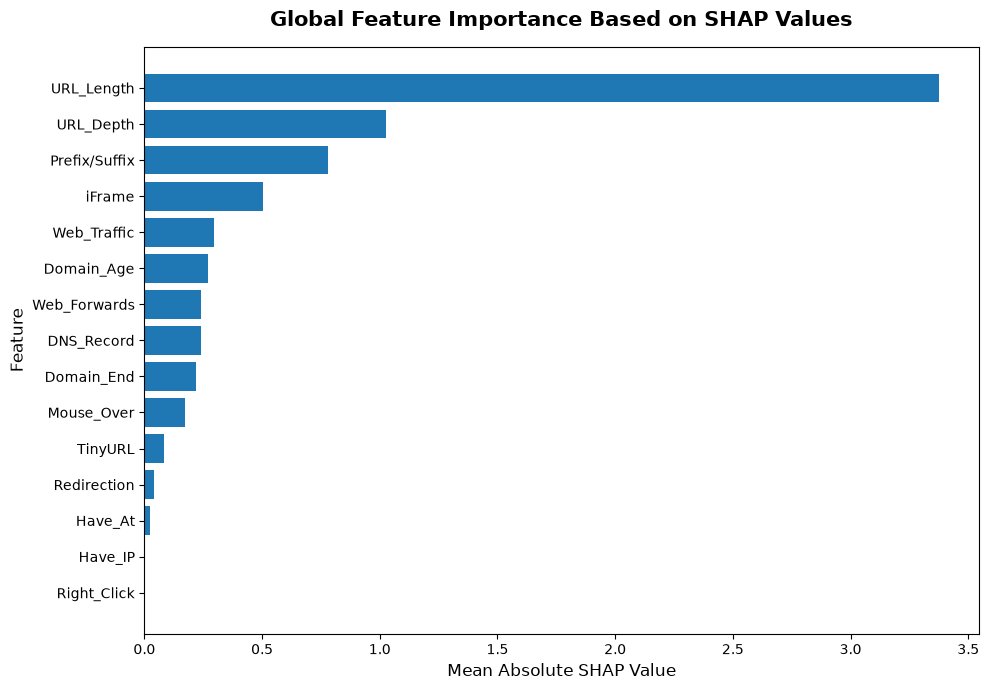

In [9]:
plt.figure(figsize=(10, 7))

shap_importance_plot = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=True
)

plt.barh(
    shap_importance_plot["Feature"],
    shap_importance_plot["Mean_Abs_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.title(
    "Global Feature Importance Based on SHAP Values",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

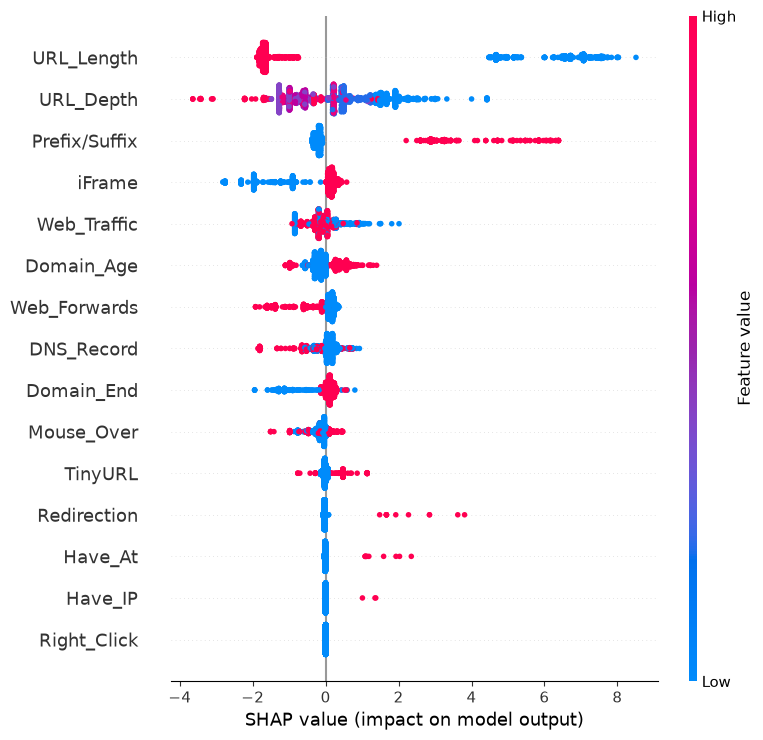

In [10]:
shap.summary_plot(
    shap_values.values,
    X_test_domain,
    feature_names=final_features,
    show=True
)

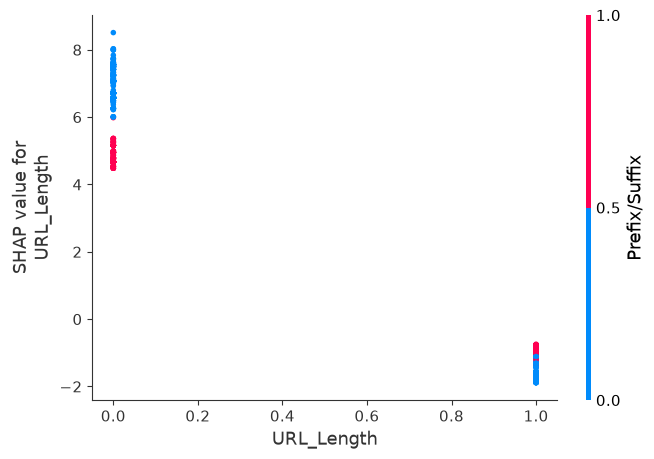

In [11]:
shap.dependence_plot(
    "URL_Length",
    shap_values.values,
    X_test_domain,
    feature_names=final_features,
    show=True
)

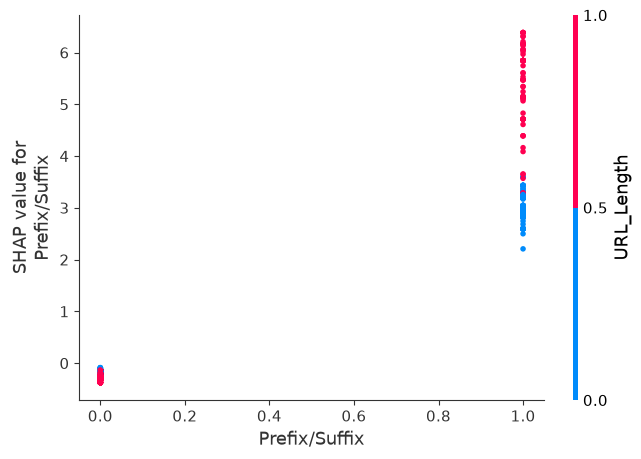

In [12]:
shap.dependence_plot(
    "Prefix/Suffix",
    shap_values.values,
    X_test_domain,
    feature_names=final_features,
    show=True
)

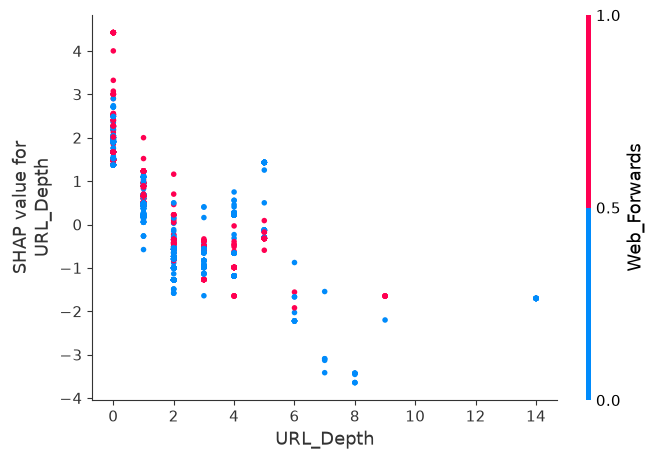

In [13]:
shap.dependence_plot(
    "URL_Depth",
    shap_values.values,
    X_test_domain,
    feature_names=final_features,
    show=True
)

In [14]:
shap_findings = shap_importance.copy()

shap_findings["Rank"] = range(1, len(shap_findings) + 1)

shap_findings = shap_findings[
    ["Rank", "Feature", "Mean_Abs_SHAP"]
]

display(
    shap_findings.round({
        "Mean_Abs_SHAP": 4
    })
)

,Rank,Feature,Mean_Abs_SHAP
0,1,URL_Length,3.3754
1,2,URL_Depth,1.0278
2,3,Prefix/Suffix,0.7815
3,4,iFrame,0.5024
4,5,Web_Traffic,0.2945
5,6,Domain_Age,0.2704
6,7,Web_Forwards,0.2414
7,8,DNS_Record,0.2397
8,9,Domain_End,0.2191
9,10,Mouse_Over,0.1721


In [18]:
import shap
import matplotlib.pyplot as plt

# Select one sample from X_test_domain
sample = google.com

# Waterfall plot
shap.plots.waterfall(
    shap_values[sample_index],
    max_display=15
)

plt.tight_layout()
plt.show()

NameError: name 'google' is not defined